In [9]:
import qlat as q
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys

sys.path.insert(0,'/home/jhildebrand28/ktopipi/')
import corr_utils as cu

from corr_utils.jackknife import *

In [10]:
importlib.reload(cu.diagrams)

<module 'corr_utils.diagrams' from '/home/jhildebrand28/ktopipi/corr_utils/diagrams.py'>

# 16IH2 fsel dataset results

### Load data

In [83]:
dst = "/home/jhildebrand28/ktopipi/results/16IH2/auto-contract-fsel-total-test/"
ext_CR1 = 'pipi_corr_psnk_psrc_1.lat'
ext_CR2 = 'pipi_corr_psnk_psrc_2.lat'
ext_psel = 'pipi_corr_psnk_psrc_psel.lat'
ext_vac = "pipi_vev.lat"

traj_list = list(range(2900,2991,10))

arr_CR1 = cu.diagrams.load_corr(dst,ext_CR1,traj_list)
arr_CR2 = cu.diagrams.load_corr(dst,ext_CR2,traj_list)
arr_psel = cu.diagrams.load_corr(dst,ext_psel,traj_list)
arr_vac = cu.diagrams.load_corr(dst,ext_vac,traj_list)

array shape: (10, 81, 14)
array shape: (10, 81, 14)
array shape: (10, 129, 14)
array shape: (10, 9, 32)


### Full correlator construction

In [84]:
tsep_max = 15
Delta = 1

#before the type sum we need to construct the vacuum term and average the two correlators in CR1 and CR2. 
arr_DCR = cu.diagrams.corr_point_avg(arr_CR1, arr_CR2)

VC = cu.diagrams.construct_V(arr_vac[:,0,:].real,arr_vac[:,0,:].real,15,1)
V_000 = cu.diagrams.construct_V(arr_vac[:,1,:].real,arr_vac[:,1,:].real,15,1)
V_001 = cu.diagrams.construct_V(arr_vac[:,3,:].real,arr_vac[:,3,:].real,15,1)
V_011 = cu.diagrams.construct_V(arr_vac[:,5,:].real,arr_vac[:,5,:].real,15,1)
V_111 = cu.diagrams.construct_V(arr_vac[:,7,:].real,arr_vac[:,7,:].real,15,1)
V = np.stack((VC,V_000, V_001, V_011, V_111),axis=1)


V_norm = counter_norm(V)
DCR_norm = counter_norm(arr_DCR)
print(DCR_norm.shape)
print(V_norm.shape)

(10, 80, 14)
(10, 4, 15)


In [85]:
#type sum. Here we sum all types present in a single isospin channel on a per configuration basis. 
I2_000 = cu.diagrams.pipi_type_sum(DCR_norm[:,0,:],DCR_norm[:,2,:])
I2_001 = cu.diagrams.pipi_type_sum(DCR_norm[:,25,:],DCR_norm[:,27,:])
I2_011 = cu.diagrams.pipi_type_sum(DCR_norm[:,50,:],DCR_norm[:,52,:])
I2_111 = cu.diagrams.pipi_type_sum(DCR_norm[:,75,:],DCR_norm[:,77,:])

pipi_I2 = np.stack((I2_000,I2_001,I2_011,I2_111),axis=1)
print(pipi_I2.shape)

(10, 4, 14)


In [86]:
#type sum. Here we sum all types present in a single isospin channel on a per configuration basis. 
I0_000 = cu.diagrams.pipi_type_sum(DCR_norm[:,1,:],DCR_norm[:,3,:],DCR_norm[:,4,:],V_norm[:,0,1:],isospin=0)
I0_001 = cu.diagrams.pipi_type_sum(DCR_norm[:,26,:],DCR_norm[:,28,:],DCR_norm[:,29,:],V_norm[:,1,1:],isospin=0)
I0_011 = cu.diagrams.pipi_type_sum(DCR_norm[:,51,:],DCR_norm[:,53,:],DCR_norm[:,54,:],V_norm[:,2,1:],isospin=0)
I0_111 = cu.diagrams.pipi_type_sum(DCR_norm[:,76,:],DCR_norm[:,78,:],DCR_norm[:,79,:],V_norm[:,3,1:],isospin=0)

pipi_I0 = np.stack((I0_000,I0_001,I0_011,I0_111),axis=1)
print(pipi_I0.shape)

(10, 4, 14)


In [88]:
pipi_I2_jks = jackblocks_all(pipi_I2,omit=[])
pipi_I0_jks = jackblocks_all(pipi_I0,omit=[])

pipi_I2_avg, pipi_I2_err = jack_all(pipi_I2_jks.real)
pipi_I0_avg, pipi_I0_err = jack_all(pipi_I0_jks.real)

print(pipi_I0_avg.shape)

(4, 14)


### comparison with psel dataset

In [89]:
tt = np.linspace(1,14,14)
ts = np.linspace(1,32,32)

In [90]:
#psel stuff
counters = arr_psel[:,0,:]

psel_000_I2 = arr_psel[:,3,:]
psel_001_I2 = arr_psel[:,43,:]
psel_011_I2 = arr_psel[:,83,:]
psel_111_I2 = arr_psel[:,123,:]

psel_000_I0 = arr_psel[:,8,:]
psel_001_I0 = arr_psel[:,48,:]
psel_011_I0 = arr_psel[:,88,:]
psel_111_I0 = arr_psel[:,128,:]

psel_I2 = np.stack((counters,psel_000_I2,psel_001_I2,psel_011_I2,psel_111_I2),axis=1)
psel_I0 = np.stack((counters,psel_000_I0,psel_001_I0,psel_011_I0,psel_111_I0),axis=1)

psel_I2_jks = jackblocks_all(psel_I2,omit=[])
psel_I0_jks = jackblocks_all(psel_I0,omit=[])

psel_I2_norm = counter_norm(psel_I2_jks)
psel_I0_norm = counter_norm(psel_I0_jks)

psel_I2_avg, psel_I2_err = jack_all(psel_I2_norm.real)
psel_I0_avg, psel_I0_err = jack_all(psel_I0_norm.real)

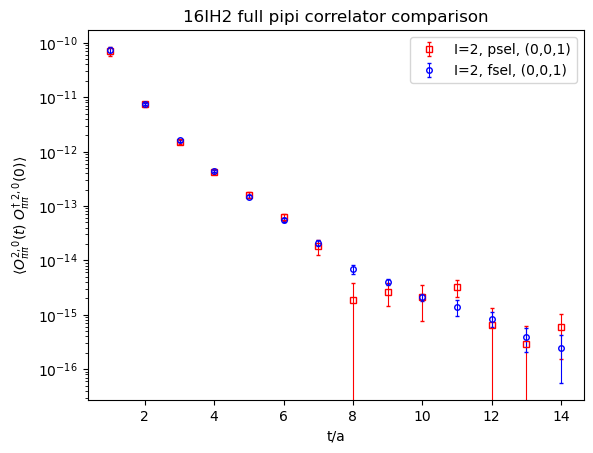

In [91]:
#plotting full correlator. 
fig, ax = plt.subplots()
#ax.errorbar(tt,psel_I2_avg[0], yerr=psel_I2_err[0], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=2, psel, (0,0,0)')
#ax.errorbar(tt,pipi_I2_avg[0], yerr=pipi_I2_err[0], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=2, fsel, (0,0,0)')

ax.errorbar(tt,psel_I2_avg[1], yerr=psel_I2_err[1], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=2, psel, (0,0,1)')
ax.errorbar(tt,pipi_I2_avg[1], yerr=pipi_I2_err[1], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=2, fsel, (0,0,1)')

#ax.errorbar(tt,psel_I2_avg[2], yerr=psel_I2_err[2], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=2, psel, (0,1,1)')
#ax.errorbar(tt,pipi_I2_avg[2], yerr=pipi_I2_err[2], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=2, fsel, (0,1,1)')

#ax.errorbar(tt,psel_I2_avg[3], yerr=psel_I2_err[3], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=2, psel, (1,1,1)')
#ax.errorbar(tt,pipi_I2_avg[3], yerr=pipi_I2_err[3], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=2, fsel, (1,1,1)')

ax.set_title('16IH2 full pipi correlator comparison')
ax.set_xlabel('t/a')
ax.set_ylabel(r'$\langle O^{2,0}_{\pi\pi}(t) \ O_{\pi\pi}^{\dagger \ 2,0}(0) \rangle$')
ax.set_yscale('log')
ax.legend();

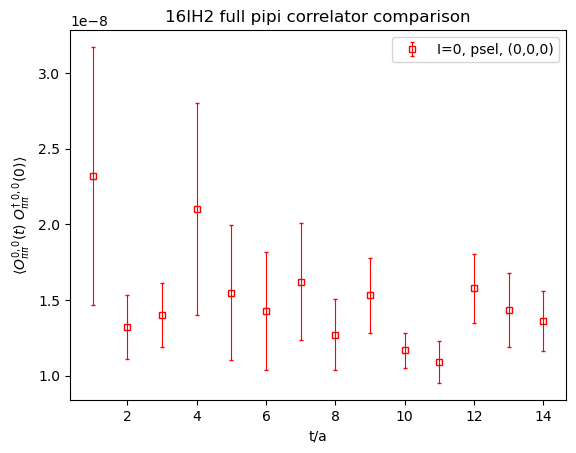

In [92]:
#plotting full correlator. 
fig, ax = plt.subplots()
ax.errorbar(tt,psel_I0_avg[0], yerr=psel_I0_err[0], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=0, psel, (0,0,0)')
#ax.errorbar(tt,pipi_I0_avg[0], yerr=pipi_I0_err[0], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=0, fsel, (0,0,0)')

#ax.errorbar(tt,psel_I0_avg[1], yerr=psel_I0_err[1], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=0, psel, (0,0,1)')
#ax.errorbar(tt,pipi_I0_avg[1], yerr=pipi_I0_err[1], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=0, fsel, (0,0,1)')

#ax.errorbar(tt,psel_I0_avg[2], yerr=psel_I0_err[2], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=0, psel, (0,1,1)')
#ax.errorbar(tt,pipi_I0_avg[2], yerr=pipi_I0_err[2], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=0, fsel, (0,1,1)')

#ax.errorbar(tt,psel_I0_avg[3], yerr=psel_I0_err[3], marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=0, psel, (1,1,1)')
#ax.errorbar(tt,pipi_I0_avg[3], yerr=pipi_I0_err[3], marker='o',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=0, fsel, (1,1,1)')

ax.set_title('16IH2 full pipi correlator comparison')
ax.set_xlabel('t/a')
ax.set_ylabel(r'$\langle O^{0,0}_{\pi\pi}(t) \ O_{\pi\pi}^{\dagger \ 0,0}(0) \rangle$')
#ax.set_yscale('log')
ax.legend();

In [69]:
psel_norm = counter_norm(arr_psel)

In [94]:
#I=0 data looks bad we look at a per diagram basis
#I0_000 = cu.diagrams.pipi_type_sum(DCR_norm[:,1,:],DCR_norm[:,3,:],DCR_norm[:,4,:],V_norm[:,0,1:],isospin=0)
fsel_000_V = V_norm[:,0,1:]
psel_000_V = psel_norm[:,6,:]

fsel_000_R = DCR_norm[:,4,:]
psel_000_R = psel_norm[:,5,:]

fsel_000_C = DCR_norm[:,3,:]
psel_000_C = psel_norm[:,3,:]

fsel_000_D = DCR_norm[:,1,:]
psel_000_D = psel_norm[:,4,:]

fsel_V_000_jks = jackblocks_all(fsel_000_V,omit=[])
psel_V_000_jks = jackblocks_all(psel_000_V,omit=[])

psel_V_avg, psel_V_err = jack_all(psel_V_000_jks.real)
fsel_V_avg, fsel_V_err = jack_all(fsel_V_000_jks.real)

psel_V_avg.shape
tt.shape

(14,)

(5e-09, 2e-08)

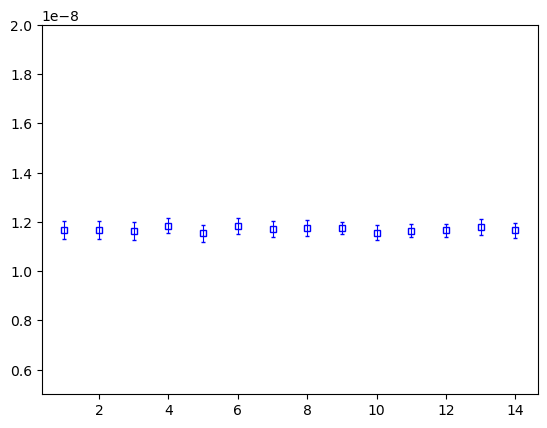

In [95]:
fig, ax=plt.subplots()

#ax.errorbar(tt,psel_V_avg, yerr=psel_V_err, marker='s',markerfacecolor='none', markersize='4',ls='',color='red',elinewidth=0.8,capsize=1.5,label='I=0, psel, (0,0,0), V')
ax.errorbar(tt,fsel_V_avg, yerr=fsel_V_err, marker='s',markerfacecolor='none', markersize='4',ls='',color='blue',elinewidth=0.8,capsize=1.5,label='I=0, fsel, (0,0,0), V')
ax.set_ylim(0.5e-8,2e-8)